<a href="https://colab.research.google.com/github/camilo299restrepo/Integracion-de-Datos-y-Prospectiva/blob/main/Reto5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Reto: Evaluación del Riesgo Operacional en Canales Electrónicos**

El presente taller aborda la evaluación del riesgo operacional en los canales electrónicos de una entidad financiera, tomando como base una serie histórica de 701 eventos diarios de fallas tecnológicas registrados en plataformas como la aplicación móvil, la sucursal virtual y los cajeros automáticos. A través de la metodología de matrices de riesgo y la técnica de clusterización K-Medoids, se busca transformar datos crudos de transacciones fallidas y pérdidas económicas en herramientas de decisión gerencial que permitan cuantificar la exposición de la organización, evaluar la eficacia de sus controles actuales y estimar métricas clave como la Pérdida Esperada (PE) y el Valor en Riesgo Operacional (OpVaR) al 99,9% de confianza, diferenciando entre el riesgo inherente —antes de la intervención de controles— y el riesgo residual —una vez aplicadas las acciones de gestión.

**0. Cargamos librerías y archivos**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
nxl = '/content/drive/MyDrive/Integración de datos y prospectiva/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0, header=1)
XDB.columns = ['Fecha', 'Trans_Diarias', 'Valor_Transado',
               'Trans_Fallidas', 'Valor_Perdida', 'Descripcion']

# Limpieza: eliminar filas sin datos numéricos
for col in ['Trans_Fallidas', 'Valor_Perdida']:
    XDB[col] = pd.to_numeric(XDB[col], errors='coerce')
XDB = XDB.dropna(subset=['Trans_Fallidas', 'Valor_Perdida']).reset_index(drop=True)

print(f"Registros cargados: {len(XDB)}")
XDB.head()

Registros cargados: 701


,Fecha,Trans_Diarias,Valor_Transado,Trans_Fallidas,Valor_Perdida,Descripcion
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


**1. Función de Clusterización**

In [3]:
np.random.seed(42)

def clusterizacion(Xi):
    # Seleccionar 5 semillas aleatorias y ordenarlas
    XC = np.random.choice(Xi, size=5)
    XC = np.sort(XC)  # Nivel 0=más bajo ... Nivel 4=más alto
    nc = np.zeros((len(Xi), 1))

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])  # Distancia a cada semilla
        nc[k] = np.argmin(d)    # Cluster más cercano
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2  # Actualizar centroide

    return XC, nc  # Centroides y nivel asignado a cada dato

In [4]:
# Variable de frecuencia: transacciones fallidas por día
Xf = np.array(XDB['Trans_Fallidas'])
XCf, ncf = clusterizacion(Xf)

# Variable de severidad: valor de pérdida (millones)
Xs = np.array(XDB['Valor_Perdida'])
XCs, ncs = clusterizacion(Xs)

# Pérdida agregada diaria: LDA = Frecuencia × Severidad
LDA = Xf * Xs
XClda, nclda = clusterizacion(LDA)

# Crear DataFrame de trabajo con todos los niveles asignados
df = pd.DataFrame(np.column_stack((Xf, ncf, Xs, ncs, LDA, nclda, XDB['Descripcion'])))
df.columns = ['Freq', 'Nivel_F', 'Sev', 'Nivel_S', 'LDA', 'Nivel_LDA', 'Descripcion']
print(df.head())

  Freq Nivel_F     Sev Nivel_S     LDA Nivel_LDA  \
0    1     0.0  0.5374     0.0  0.5374       0.0   
1    4     0.0  1.1978     2.0  4.7912       2.0   
2    5     1.0  0.4269     0.0  2.1345       1.0   
3    6     1.0  1.0814     1.0  6.4884       3.0   
4    7     2.0  1.2105     2.0  8.4735       4.0   

                                         Descripcion  
0  Errores visuales menores, problemas de usabili...  
1  Errores en la interfaz de usuario, fallas en f...  
2  Errores visuales menores, problemas de usabili...  
3  Errores en la interfaz de usuario, fallas en f...  
4  Errores en la interfaz de usuario, fallas en f...  


**2. Construcción de las matrices**

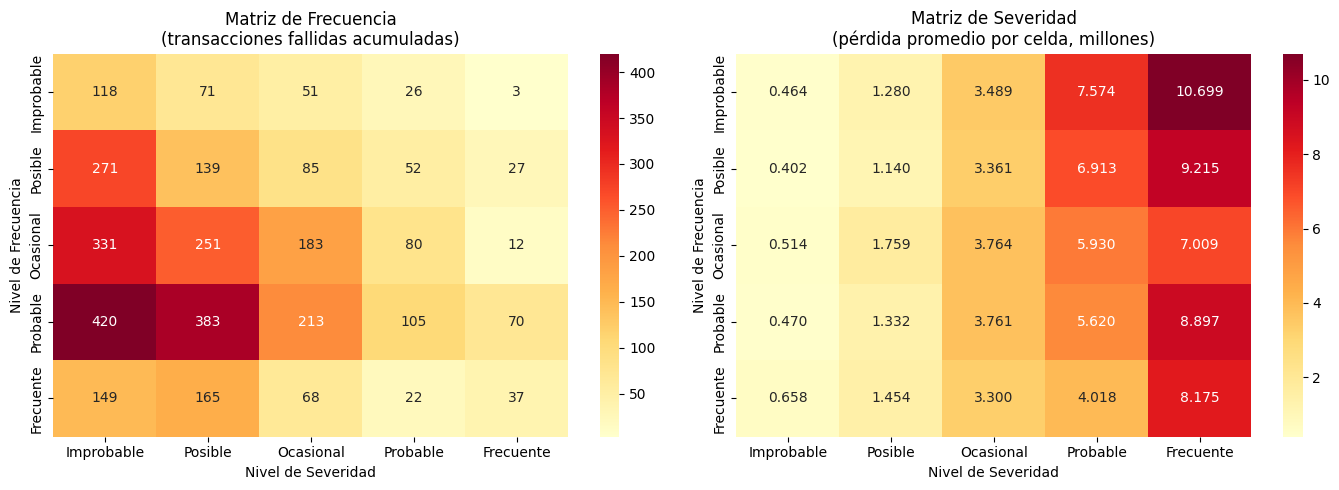

In [5]:
MEf = np.zeros((5, 5))  # Acumula transacciones fallidas
MEs = np.zeros((5, 5))  # Promedia la severidad (pérdida en millones)

for k in range(len(Xf)):
    nf = np.int32(df.iloc[k, 1])  # Nivel de frecuencia (fila)
    ns = np.int32(df.iloc[k, 3])  # Nivel de severidad (columna)
    MEf[nf, ns] = MEf[nf, ns] + Xf[k]
    MEs[nf, ns] = (MEs[nf, ns] + Xs[k]) / 2  # Promedio acumulado

# Etiquetas de los 5 niveles
niveles = ['Improbable', 'Posible', 'Ocasional', 'Probable', 'Frecuente']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            xticklabels=niveles, yticklabels=niveles)
axes[0].set_title('Matriz de Frecuencia\n(transacciones fallidas acumuladas)')
axes[0].set_xlabel('Nivel de Severidad')
axes[0].set_ylabel('Nivel de Frecuencia')

sns.heatmap(MEs, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            xticklabels=niveles, yticklabels=niveles)

axes[1].set_title('Matriz de Severidad\n(pérdida promedio por celda, millones)')
axes[1].set_xlabel('Nivel de Severidad')
axes[1].set_ylabel('Nivel de Frecuencia')

plt.tight_layout()
plt.show()

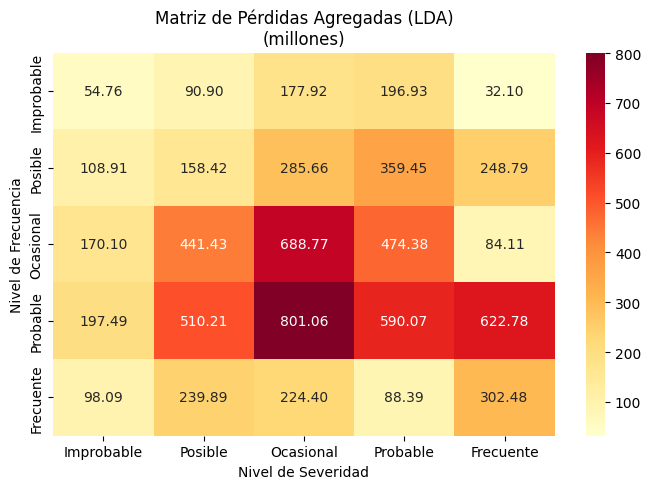

In [6]:
MLDA = MEf * MEs  # Pérdida agregada = Frecuencia × Severidad promedio

plt.figure(figsize=(7, 5))
sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Pérdidas Agregadas (LDA)\n(millones)')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.tight_layout()
plt.show()

In [7]:
# Convertir columnas numéricas (vienen como object por el column_stack)
for col in ['Freq', 'Nivel_F', 'Sev', 'Nivel_S', 'LDA', 'Nivel_LDA']:
    df[col] = pd.to_numeric(df[col])
df['Nivel_F'] = df['Nivel_F'].astype(int)
df['Nivel_S'] = df['Nivel_S'].astype(int)
df['Nivel_LDA'] = df['Nivel_LDA'].astype(int)

df.to_excel('MatrizRiesgo_Canales.xlsx', index=False)
print("Archivo guardado: MatrizRiesgo_Canales.xlsx")

Archivo guardado: MatrizRiesgo_Canales.xlsx


**3. Matriz de impacto y gestión**

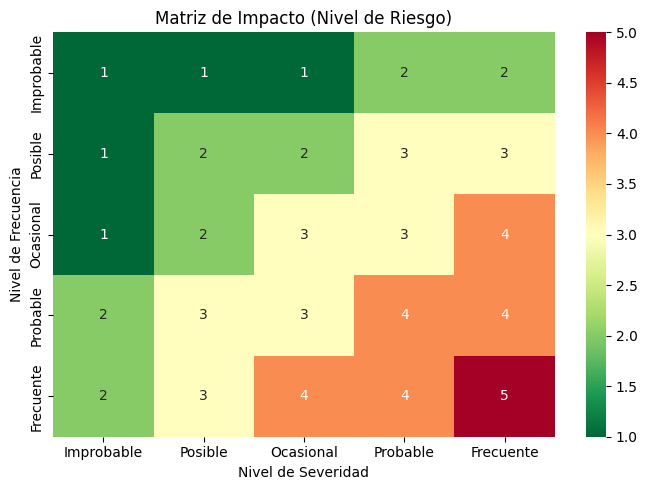

In [8]:
MI = np.array([[1,1,1,2,2],
               [1,2,2,3,3],
               [1,2,3,3,4],
               [2,3,3,4,4],
               [2,3,4,4,5]])

plt.figure(figsize=(7, 5))
sns.heatmap(MI, annot=True, fmt='.0f', cmap='RdYlGn_r',
            xticklabels=niveles, yticklabels=niveles, vmin=1, vmax=5)
plt.title('Matriz de Impacto (Nivel de Riesgo)')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.tight_layout()
plt.show()

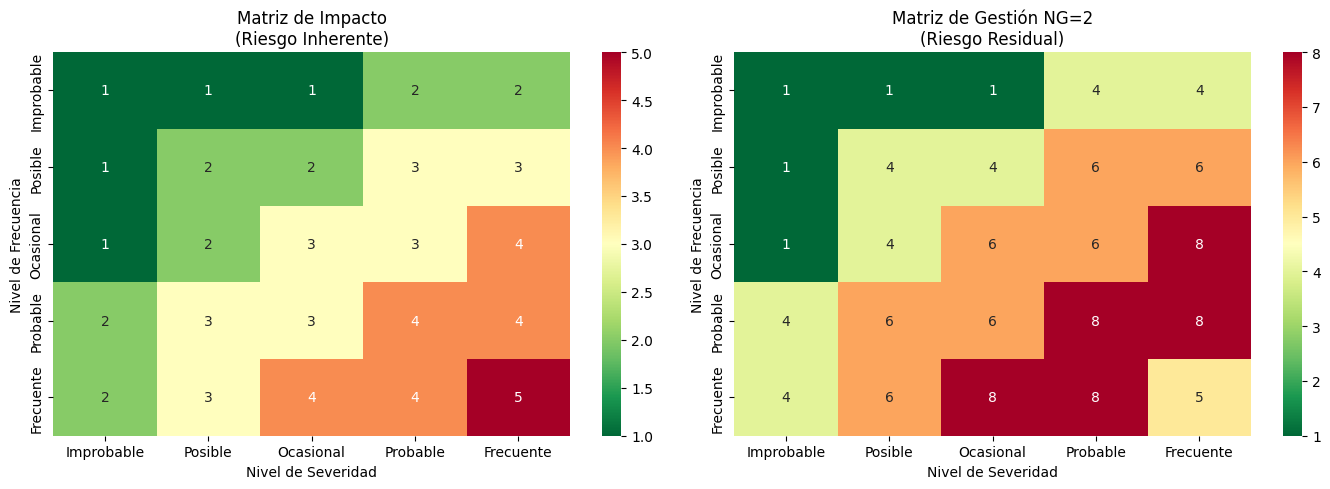

In [9]:
# Nivel de gestión: 1 = básico, 2 = estándar, 3 = robusto, 4 = avanzado
NG = 2  # Cambia este valor para comparar escenarios

MG = np.copy(MI)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:
            MG[i, j] = MG[i, j] * NG

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(MI, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[0],
            xticklabels=niveles, yticklabels=niveles)
axes[0].set_title('Matriz de Impacto\n(Riesgo Inherente)')
axes[0].set_xlabel('Nivel de Severidad')
axes[0].set_ylabel('Nivel de Frecuencia')

sns.heatmap(MG, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[1],
            xticklabels=niveles, yticklabels=niveles)
axes[1].set_title(f'Matriz de Gestión NG={NG}\n(Riesgo Residual)')
axes[1].set_xlabel('Nivel de Severidad')
axes[1].set_ylabel('Nivel de Frecuencia')

plt.tight_layout()
plt.show()

**4. Pérdida Esperada (PE) y OpVaR al 99,9%**

In [10]:
# 1. Promedio simple: igual peso a todas las celdas
PE_simple = np.mean(MEs)
print(f"PE simple:                       {PE_simple:.4f} M")

# 2. Promedio ponderado por frecuencia: más peso a las celdas con más eventos
PE_pond = np.sum(MEf * MEs) / np.sum(MEf)
print(f"PE ponderada por frecuencia:       {PE_pond:.4f} M")

# 3. Ponderada por impacto: pondera también el nivel de riesgo de cada celda
PE_impacto = np.sum(MEf * MI * MEs) / np.sum(MEf * MI)
print(f"PE ponderada por impacto:          {PE_impacto:.4f} M")

# 4. Ponderada por gestión (Riesgo Residual): refleja el efecto de los controles
PE_gestion = np.sum(MEf * MI * MEs) / np.sum(MEf * MG)
print(f"PE ponderada por gestión (NG={NG}):  {PE_gestion:.4f} M")

PE simple:                       4.0478 M
PE ponderada por frecuencia:       2.1751 M
PE ponderada por impacto:          2.8118 M
PE ponderada por gestión (NG=2):  1.5079 M


In [11]:
from scipy.stats import norm

z_999 = norm.ppf(0.999)  # ≈ 3.0902
print(f"z al 99.9%: {z_999:.4f}")

# --- ESCENARIO INHERENTE (sin gestión) ---
# Pérdidas diarias brutas de la base de datos
perdidas_inherentes = df['LDA'].values.astype(float)
mu_i  = np.mean(perdidas_inherentes)
std_i = np.std(perdidas_inherentes)
OpVaR_inherente = mu_i + z_999 * std_i

print(f"\n--- Riesgo Inherente ---")
print(f"Media pérdidas diarias:   {mu_i:.4f} M")
print(f"Desv. estándar:          {std_i:.4f} M")
print(f"OpVaR 99.9%:             {OpVaR_inherente:.4f} M")

# --- ESCENARIO RESIDUAL (con gestión NG) ---
# Ajustamos cada pérdida por el factor de gestión de su celda
factor_gestion = np.array([MG[df.iloc[k,1], df.iloc[k,3]] / MI[df.iloc[k,1], df.iloc[k,3]]
                        if MI[df.iloc[k,1], df.iloc[k,3]] > 0 else 1
                        for k in range(len(df))])
perdidas_residuales = perdidas_inherentes / factor_gestion
mu_r  = np.mean(perdidas_residuales)
std_r = np.std(perdidas_residuales)
OpVaR_residual = mu_r + z_999 * std_r

print(f"\n--- Riesgo Residual (NG={NG}) ---")
print(f"Media pérdidas ajustadas: {mu_r:.4f} M")
print(f"Desv. estándar:          {std_r:.4f} M")
print(f"OpVaR 99.9%:             {OpVaR_residual:.4f} M")

reduccion = OpVaR_inherente - OpVaR_residual
print(f"\nReducción por gestión:    {reduccion:.4f} M")
print(f"Eficacia del control:     {reduccion/OpVaR_inherente*100:.1f}%")

z al 99.9%: 3.0902

--- Riesgo Inherente ---
Media pérdidas diarias:   9.4511 M
Desv. estándar:          13.7075 M
OpVaR 99.9%:             51.8104 M

--- Riesgo Residual (NG=2) ---
Media pérdidas ajustadas: 5.4321 M
Desv. estándar:          8.2083 M
OpVaR 99.9%:             30.7975 M

Reducción por gestión:    21.0129 M
Eficacia del control:     40.6%


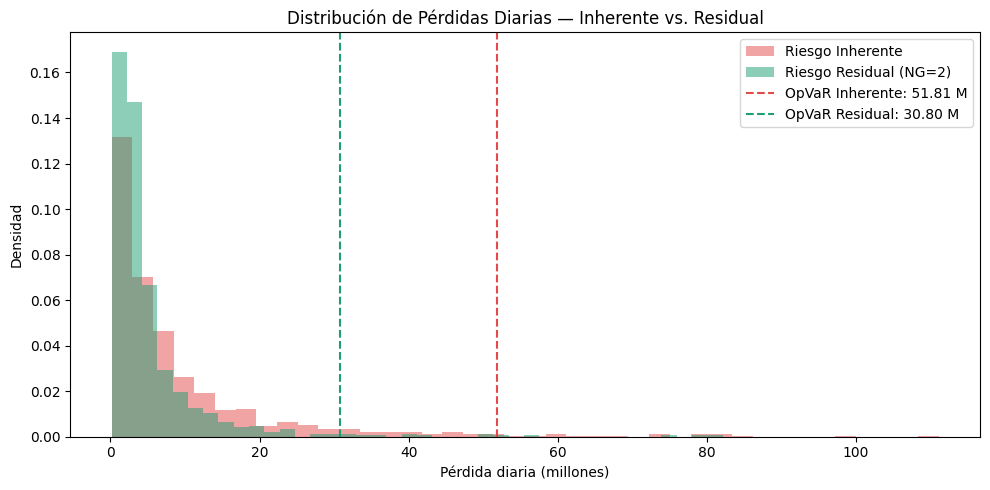

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(perdidas_inherentes, bins=40, alpha=0.5, color='#E24B4A',
        label='Riesgo Inherente', density=True)
ax.hist(perdidas_residuales, bins=40, alpha=0.5, color='#1D9E75',
        label=f'Riesgo Residual (NG={NG})', density=True)

ax.axvline(OpVaR_inherente, color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'OpVaR Inherente: {OpVaR_inherente:.2f} M')
ax.axvline(OpVaR_residual, color='#1D9E75', linestyle='--', linewidth=1.5,
           label=f'OpVaR Residual: {OpVaR_residual:.2f} M')

ax.set_title('Distribución de Pérdidas Diarias — Inherente vs. Residual')
ax.set_xlabel('Pérdida diaria (millones)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

**5. Herramienta de auditoría**

In [13]:
def auditoria_celda(nivel_freq, nivel_sev, df_trabajo, XDB):
    """
    Filtra y muestra los eventos de una celda específica
    de la matriz de pérdidas.
    nivel_freq: 0 (Improbable) → 4 (Frecuente)
    nivel_sev: 0 (Insignificante) → 4 (Catastrófico)
    """
    niveles = ['Improbable','Posible','Ocasional','Probable','Frecuente']

    # Filtrar filas que pertenecen a la celda seleccionada
    mascara = (df_trabajo['Nivel_F'] == nivel_freq) & \
              (df_trabajo['Nivel_S'] == nivel_sev)
    indices = df_trabajo[mascara].index

    if len(indices) == 0:
        print(f"Sin eventos en celda [{niveles[nivel_freq]}, {niveles[nivel_sev]}]")
        return None

    # Construir tabla de detalle cruzando con la base original
    resultado = XDB.iloc[indices][['Fecha', 'Trans_Fallidas',
                                  'Valor_Perdida', 'Descripcion']].copy()
    resultado['LDA'] = df_trabajo.loc[indices, 'LDA'].values

    # Resumen estadístico de la celda
    print(f"╔══ AUDITORÍA DE CELDA ══════════════════════════╗")
    print(f" Frecuencia : {niveles[nivel_freq]} (nivel {nivel_freq})")
    print(f" Severidad : {niveles[nivel_sev]} (nivel {nivel_sev})")
    print(f" Nº eventos : {len(indices)}")
    print(f" Pérdida total : {resultado['LDA'].sum():.4f} M")
    print(f" Pérdida promedio: {resultado['LDA'].mean():.4f} M")
    print(f" Pérdida máxima : {resultado['LDA'].max():.4f} M")
    print(f"╚═══════════════════════════════════════════════╝")

    return resultado

╔══ AUDITORÍA DE CELDA ══════════════════════════╗
 Frecuencia : Probable (nivel 3)
 Severidad : Ocasional (nivel 2)
 Nº eventos : 21
 Pérdida total : 606.6109 M
 Pérdida promedio: 28.8862 M
 Pérdida máxima : 63.2480 M
╚═══════════════════════════════════════════════╝


,Fecha,Trans_Fallidas,Valor_Perdida,Descripcion,LDA
0,2009-01-21,10,1.4141,"Errores en la interfaz de usuario, fallas en f...",14.1410
1,2009-02-16,9,1.6694,"Errores en la interfaz de usuario, fallas en f...",15.0246
2,2009-04-27,8,1.6379,"Errores en la interfaz de usuario, fallas en f...",13.1032
3,2009-04-29,8,3.3024,"Degradación del rendimiento por varias horas, ...",26.4192
4,2009-05-06,8,1.9707,"Errores en la interfaz de usuario, fallas en f...",15.7656
5,2009-05-28,12,2.3534,"Errores en la interfaz de usuario, fallas en f...",28.2408
6,2009-06-05,9,2.0749,"Errores en la interfaz de usuario, fallas en f...",18.6741
7,2009-06-23,10,2.3131,"Errores en la interfaz de usuario, fallas en f...",23.1310
8,2009-07-18,14,2.8104,"Degradación del rendimiento por varias horas, ...",39.3456
9,2009-08-24,10,2.2858,"Errores en la interfaz de usuario, fallas en f...",22.8580


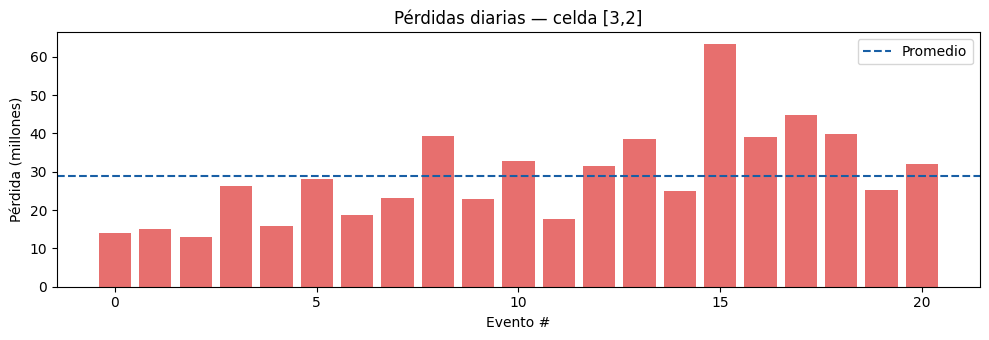

In [17]:
# Ejemplo: celda Probable (3) × Moderado (2)
nivel_freq = 3
nivel_sev  = 2

tabla = auditoria_celda(nivel_freq, nivel_sev, df, XDB)

if tabla is not None:
    display(tabla.reset_index(drop=True))

    # Gráfico de pérdidas diarias de la celda
    plt.figure(figsize=(10, 3.5))
    plt.bar(range(len(tabla)), tabla['LDA'].values, color='#E24B4A', alpha=0.8)
    plt.axhline(tabla['LDA'].mean(), color='#185FA5', linestyle='--',
                linewidth=1.5, label='Promedio')
    plt.title(f'Pérdidas diarias — celda [{nivel_freq},{nivel_sev}]')
    plt.xlabel('Evento #')
    plt.ylabel('Pérdida (millones)')
    plt.legend()
    plt.tight_layout()
    plt.show()

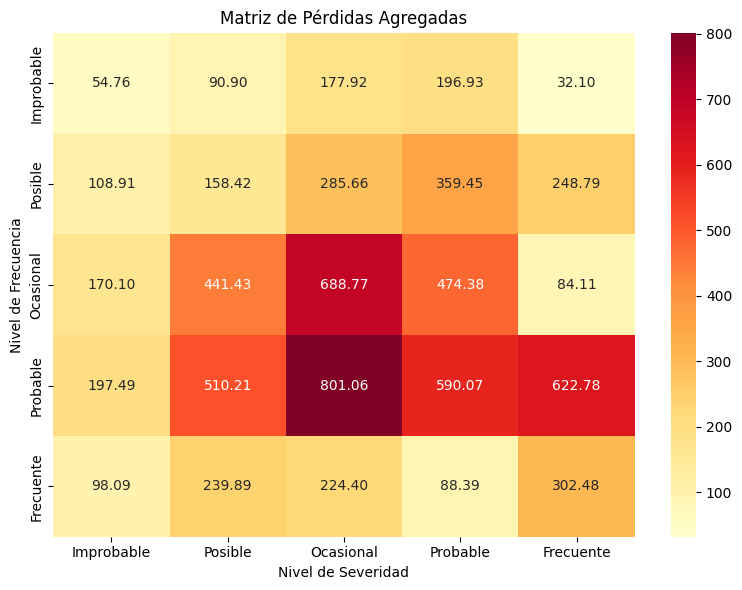

In [18]:
import ipywidgets as widgets
from IPython.display import display as ipy_display, clear_output

# Dropdowns para seleccionar la celda
dd_freq = widgets.Dropdown(options=[(label, i) for i, label in enumerate(niveles)], description='Frecuencia:', value=0)
dd_sev  = widgets.Dropdown(options=[(label, i) for i, label in enumerate(niveles)], description='Severidad:',  value=0)
btn     = widgets.Button(description='Auditar celda', button_style='primary')
output  = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        nf = dd_freq.value
        ns = dd_sev.value
        tabla = auditoria_celda(nf, ns, df, XDB)
        if tabla is not None:
            ipy_display(tabla.reset_index(drop=True))
            fig2, ax2 = plt.subplots(figsize=(10, 3.5))
            ax2.bar(range(len(tabla)), tabla['LDA'].values, color='#E24B4A', alpha=0.8)
            ax2.axhline(tabla['LDA'].mean(), color='#185FA5', linestyle='--', linewidth=1.5, label='Promedio')
            ax2.set_title(f'Pérdidas diarias — celda [{nf},{ns}]')
            ax2.set_xlabel('Evento #')
            ax2.set_ylabel('Pérdida (millones)')
            ax2.legend()
            plt.tight_layout()
            plt.show()

btn.on_click(on_click)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            xticklabels=niveles, yticklabels=niveles)
ax.set_title('Matriz de Pérdidas Agregadas')
ax.set_xlabel('Nivel de Severidad')
ax.set_ylabel('Nivel de Frecuencia')
plt.tight_layout()
plt.show()

ipy_display(widgets.VBox([dd_freq, dd_sev, btn, output]))